In [7]:
# Centralized Imports and Dataset Setup
import os
import kagglehub
import random
import matplotlib.pyplot as plt
from PIL import Image

# Download dataset once and define base paths
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
dataset_path = os.path.join(
    path,
    "Skin cancer ISIC The International Skin Imaging Collaboration"
)
train_path = os.path.join(dataset_path, "Train")

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.


In [8]:
# path is already defined in the setup cell
print(path)

/kaggle/input/skin-cancer9-classesisic


In [9]:
# os is already imported in the setup cell
print(os.listdir(path))

['Skin cancer ISIC The International Skin Imaging Collaboration']


#Print Data Set

In [10]:
# os and kagglehub are imported, path and dataset_path are defined in the setup cell
print(os.listdir(dataset_path))

['Test', 'Train']


#Count Images

In [11]:
# Imports and path definitions are now in the setup cell

print("Train Path:", train_path)
print()

class_counts = {}

for class_name in sorted(os.listdir(train_path)):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        image_count = len([
            file for file in os.listdir(class_folder)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        class_counts[class_name] = image_count

print("Number of Images Per Class")
print("-"*40)

for cls, count in class_counts.items():
    print(f"{cls:<25} {count}")

Train Path: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train

Number of Images Per Class
----------------------------------------
actinic keratosis         114
basal cell carcinoma      376
dermatofibroma            95
melanoma                  438
nevus                     357
pigmented benign keratosis 462
seborrheic keratosis      77
squamous cell carcinoma   181
vascular lesion           139


#Calculate Total Images

In [5]:
total_images = sum(class_counts.values())

print("="*40)
print("Total Training Images:", total_images)
print("="*40)

Total Training Images: 2239


#Visualize the Dataset

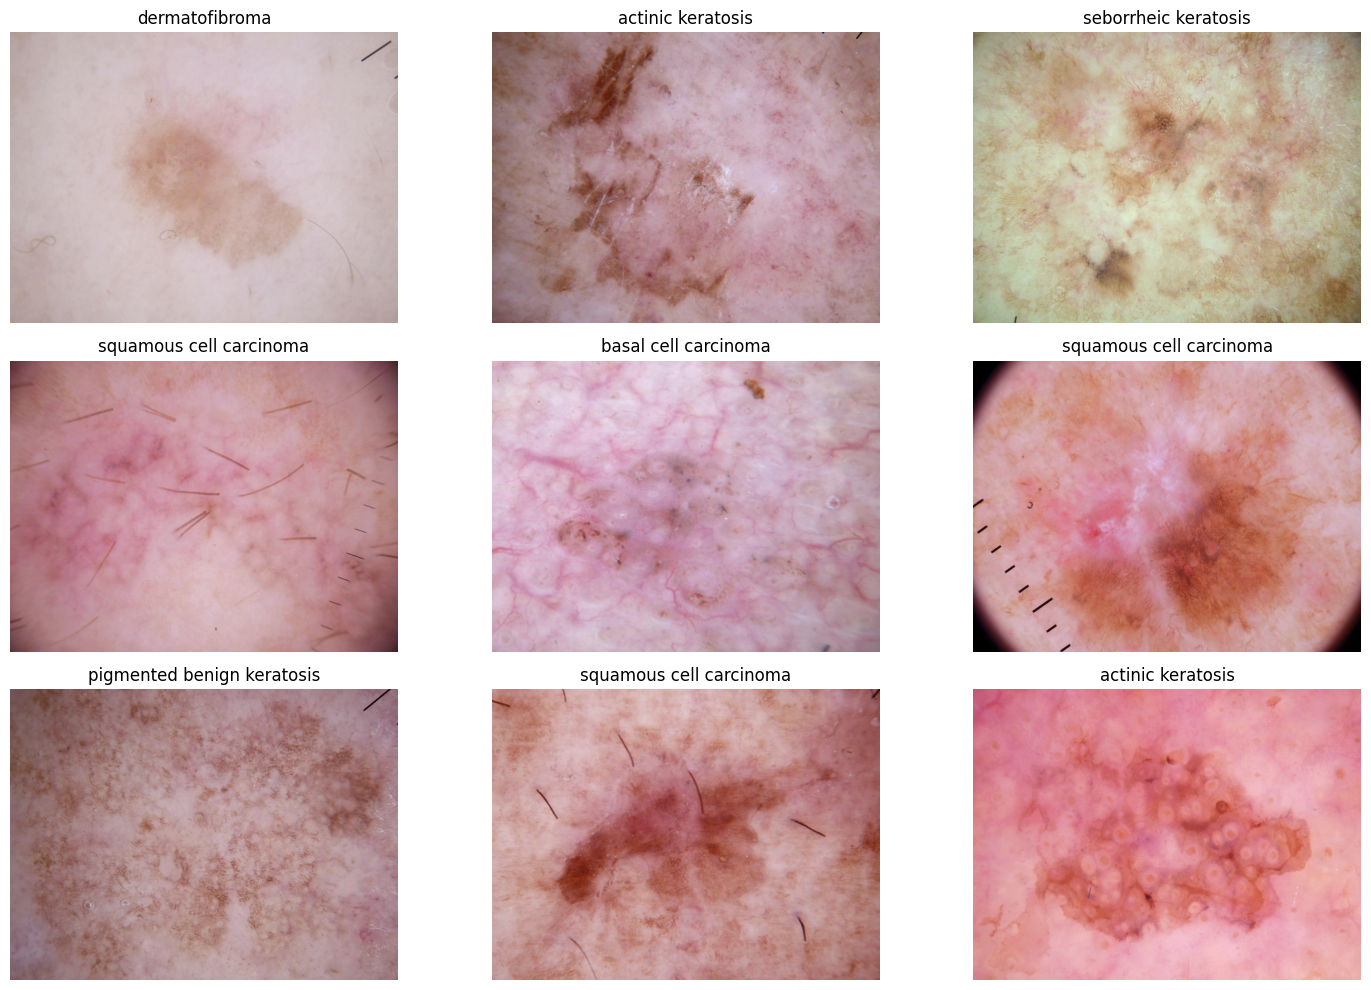

In [12]:
# Imports and path definitions are now in the setup cell

plt.figure(figsize=(15,10))

classes = sorted(os.listdir(train_path)) # train_path is from setup cell

for i in range(9):
    class_name = random.choice(classes)
    class_folder = os.path.join(train_path, class_name)
    image_name = random.choice(os.listdir(class_folder))
    image_path = os.path.join(class_folder, image_name)
    image = Image.open(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

#Display Image Size

In [3]:
sample_class = random.choice(classes)

sample_folder = os.path.join(train_path, sample_class)

sample_image = random.choice(os.listdir(sample_folder))

image = Image.open(os.path.join(sample_folder, sample_image))

print("Image Size:", image.size)

Image Size: (600, 450)


#Plot Class Distribution

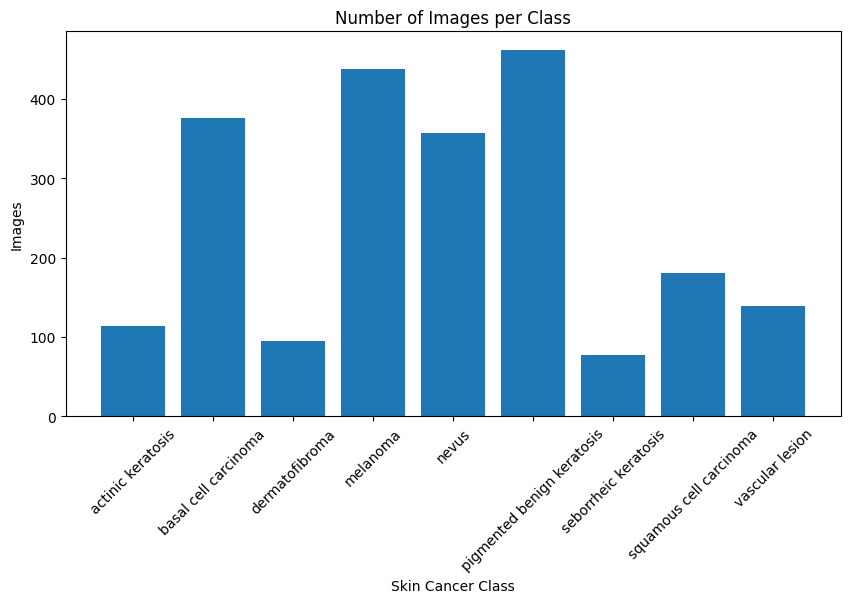

In [13]:
# Imports and class_counts calculation are now in the setup cell and kbMmzGqU9NPA respectively

plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values()) # class_counts from kbMmzGqU9NPA
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.xlabel("Skin Cancer Class")
plt.ylabel("Images")
plt.show()